# Validate Test Cases
Run `Model/pipeline.py` against `images/test_cases.json` and score against ground truth.

In [1]:
import json, sys
from pathlib import Path

REPO = Path.cwd()
MODEL_DIR = REPO / 'Model'
IMG_DIR = REPO / 'images'
TESTS = IMG_DIR / 'test_cases.json'
OUT_DIR = REPO / 'out_validate'
OUT_DIR.mkdir(exist_ok=True)

if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

from pipeline import EdgePipeline, draw, COCO
print('pipeline imported. COCO classes:', len(COCO))

pipeline imported. COCO classes: 80


In [2]:
cases = json.loads(TESTS.read_text())
for c in cases:
    gt = c.get('ground_truth') or c.get('ground_truth_bbox')
    c['gt'] = gt
print(f'{len(cases)} test cases loaded')
cases[:2]

11 test cases loaded


[{'test_id': 1,
  'prompt': 'something to sleep comfortably on',
  'image_file': 'images/000000000632.jpg',
  'ground_truth': 'bed',
  'gt': 'bed'},
 {'test_id': 2,
  'prompt': 'something which can be used to type a document',
  'image_file': 'images/000000002157.jpg',
  'ground_truth_bbox': 'keyboard',
  'gt': 'keyboard'}]

In [3]:
pipe = EdgePipeline()

[yolo] loading D:\DVCon\DVCon-SittingDucks\Model\yolo26n.pt


[yolo] ready. classes=80


[m2v] loading from D:\DVCon\DVCon-SittingDucks\Model\potion-base-8M


[m2v] ready. coco_embs=(80, 256)


In [4]:
# GT normalization: handle aliases (e.g. 'table' -> 'dining table')
ALIAS = {
    'table': 'dining table',
    'tv monitor': 'tv',
    'cellphone': 'cell phone',
}

def gt_match(pred_name: str, gt: str) -> bool:
    if not gt:
        return False
    g = gt.strip().lower()
    g = ALIAS.get(g, g)
    return pred_name.strip().lower() == g

results = []
for c in cases:
    img = (REPO / c['image_file']).resolve()
    if not img.exists():
        print(f"[skip] test {c['test_id']} missing image: {img}")
        results.append({**c, 'pred': None, 'ok': False, 'reason': 'missing image'})
        continue
    print(f"\n=== test {c['test_id']}: {c['prompt']!r} gt={c['gt']!r} img={img.name}")
    best, ranked, winners = pipe.run(img, c['prompt'], conf=0.05)
    if best is None:
        results.append({**c, 'pred': None, 'ok': False, 'reason': 'no detections'})
        continue
    out_path = OUT_DIR / f"test{c['test_id']:02d}_{img.stem}.jpg"
    draw(img, winners, c['prompt'], out_path)
    ok = gt_match(best['name'], c['gt'])
    results.append({
        'test_id': c['test_id'], 'prompt': c['prompt'], 'gt': c['gt'],
        'pred': best['name'], 'score': best['score'], 'sem': best['sem'], 'conf': best['conf'],
        'out': str(out_path), 'ok': ok,
    })
    print(f"  -> pred={best['name']} ok={ok}")


=== test 1: 'something to sleep comfortably on' gt='bed' img=000000000632.jpg


[parallel] detect=256.0ms  semantic=256.0ms  (wallclock=256.0ms)


[detect] raw detections: 34


[semantic] top5 classes for prompt:


  bed                1.000


...

  umbrella           0.750


  cup                0.699


[rank] best class='vase'  winner_count=1


  vase               score=0.477 sem=0.609 conf=0.081


  -> pred=vase ok=False

In [5]:
# Summary table
passed = sum(1 for r in results if r.get('ok'))
total = len(results)
print(f'PASS {passed}/{total} = {passed/total*100:.1f}%')
print()
print(f"{'id':>3} {'ok':>3} {'gt':<14} {'pred':<14} {'score':>6}  prompt")
for r in results:
    print(f"{r['test_id']:>3} {('Y' if r.get('ok') else 'N'):>3} {str(r.get('gt','')):<14} {str(r.get('pred','')):<14} {r.get('score',0):>6.3f}  {r.get('prompt','')}")

PASS 6/11 = 54.5%

 id  ok gt             pred            score  prompt
  1   Y bed            bed             0.975  something to sleep comfortably on
  2   N keyboard       dining table    0.714  something which can be used to type a document
  3   N wine glass     keyboard        0.602  something into which we can pour a drink
  4   Y knife          knife           0.594  something to cut a birthday cake
  5   Y chair          chair           0.982  something to sit comfortably on
  6   Y car            car             0.664  something which can be used to travel to work
  7   Y refrigerator   refrigerator    0.913  something to store and preserve ice cream
  8   Y bed            bed             0.960  something where i can rest and sleep
  9   N cup            bottle          0.755  something onto which we can be pour water
 10   N cup            bottle          0.820  something i can use to drink tea with
 11   N table          vase            0.477  the best place to keep a jug f

**test 1** — gt=`bed` pred=`bed` ok=`True`

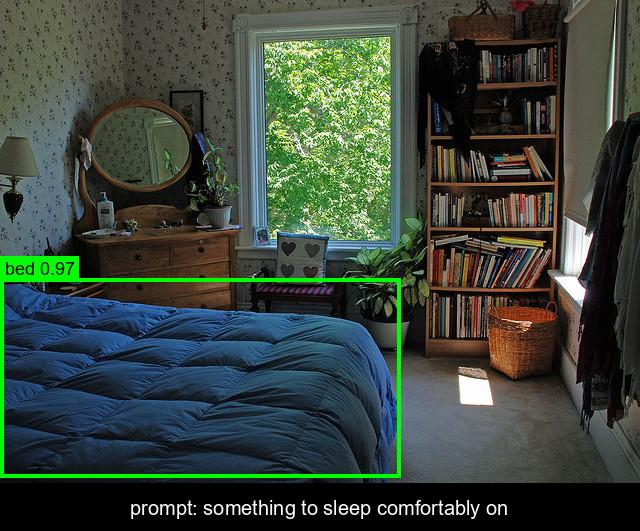

**test 2** — gt=`keyboard` pred=`dining table` ok=`False`

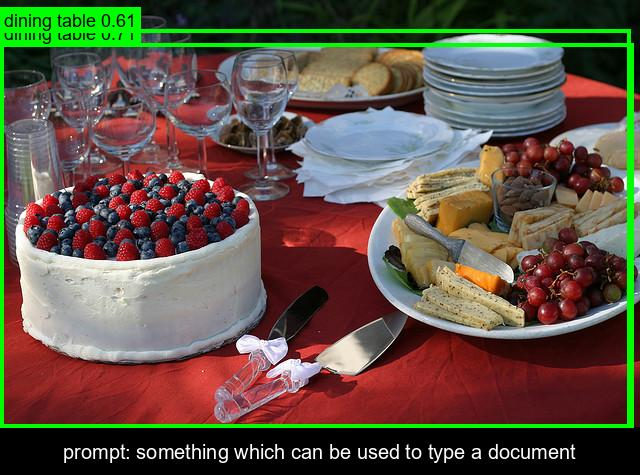

**test 3** — gt=`wine glass` pred=`keyboard` ok=`False`

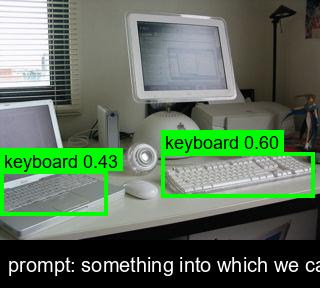

**test 4** — gt=`knife` pred=`knife` ok=`True`

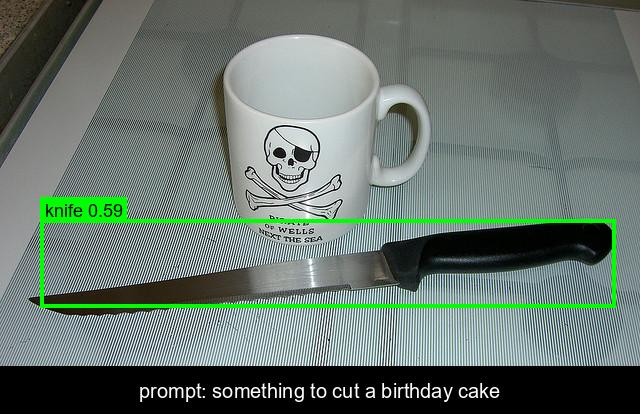

**test 5** — gt=`chair` pred=`chair` ok=`True`

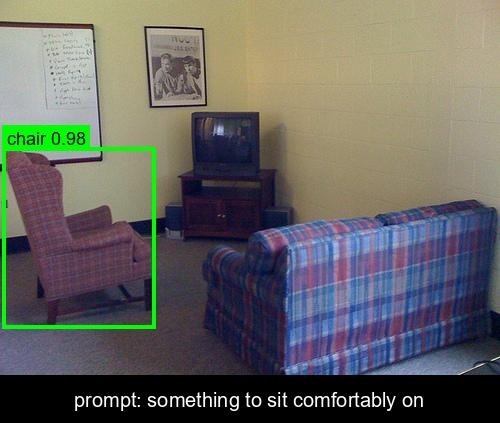

**test 6** — gt=`car` pred=`car` ok=`True`

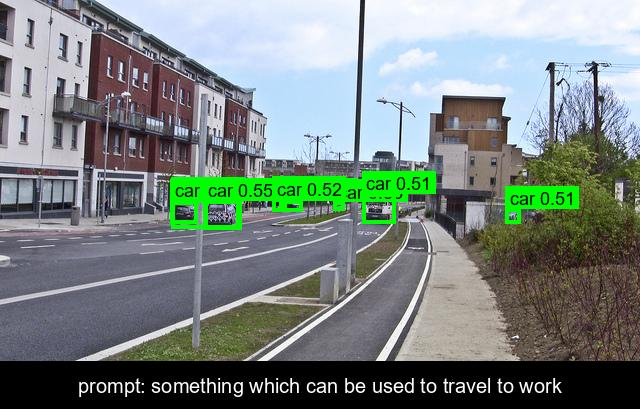

**test 7** — gt=`refrigerator` pred=`refrigerator` ok=`True`

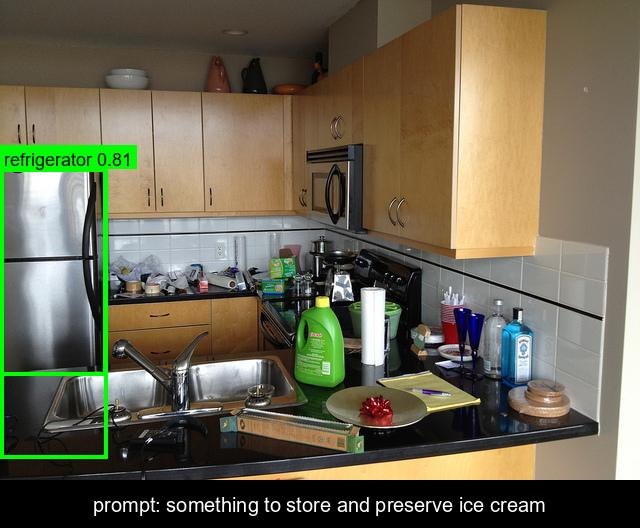

**test 8** — gt=`bed` pred=`bed` ok=`True`

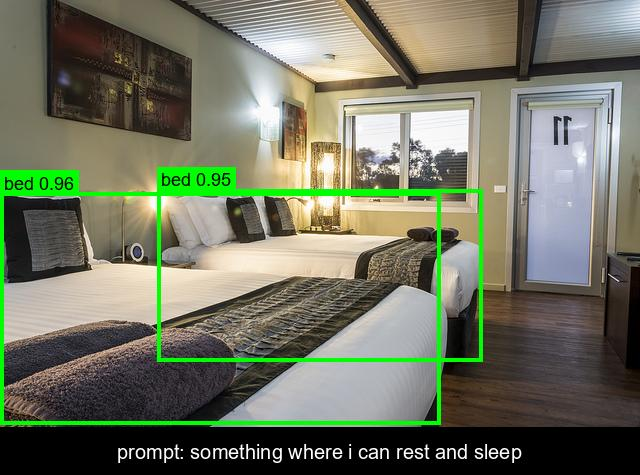

**test 9** — gt=`cup` pred=`bottle` ok=`False`

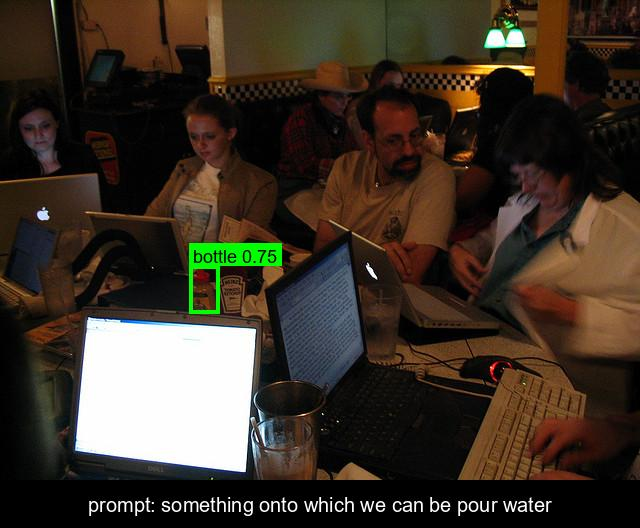

**test 10** — gt=`cup` pred=`bottle` ok=`False`

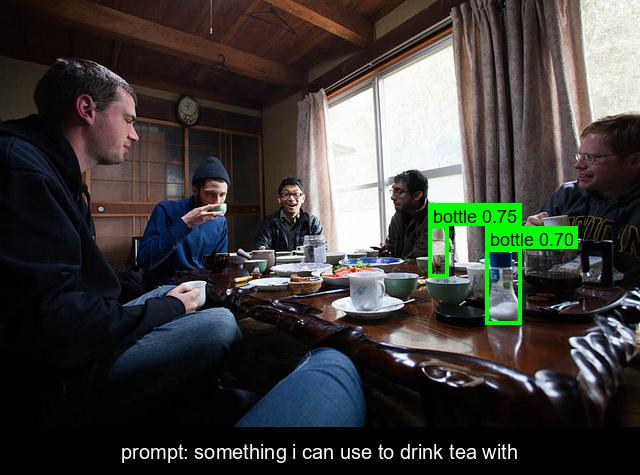

**test 11** — gt=`table` pred=`vase` ok=`False`

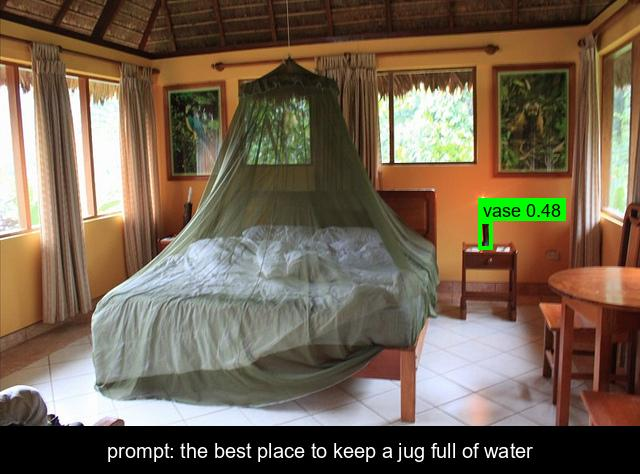

In [6]:
# Show annotated outputs inline
from IPython.display import Image as IPyImage, display, Markdown
for r in results:
    if r.get('out'):
        display(Markdown(f"**test {r['test_id']}** — gt=`{r['gt']}` pred=`{r['pred']}` ok=`{r['ok']}`"))
        display(IPyImage(r['out']))

In [7]:
# Dump results json
report = OUT_DIR / 'results.json'
report.write_text(json.dumps(results, indent=2))
print('wrote', report)

wrote D:\DVCon\DVCon-SittingDucks\out_validate\results.json
